# 06 · Explainable AI — SHAP (Phase 10)

How the final model (pressure-free logistic regression) turns inputs into a Fire Risk Score.

- **SHAP values** are exact interventional Shapley values on the *raw inputs* (fuel, O₂, CO₂, He, droplet
  diameter), in **Fire Risk points**: `average test + Σ contributions = Fire Risk` exactly. Computed by
  `scripts/explain_model.py` → `reports/phase10/`. The standard (symmetric) values are cross-checked against
  `shap.explainers.Exact` in the tests.
- **Fuel first (asymmetric Shapley values, Frye et al., NeurIPS 2020):** the model's droplet-size effect has
  opposite signs for the two fuels. Standard SHAP splits that interaction evenly, so a methanol droplet's size
  contribution would borrow heptane's slope (section 2 shows this). Fuel is therefore treated as context set first;
  atmosphere and droplet size are then explained *for that fuel*.
- **Grouped view (primary):** O₂, CO₂ and He form one player, "atmosphere". FLEX varied O₂ and suppressant together,
  so moving them independently would evaluate atmospheres that were never tested.
- **Detailed view:** per gas, for transparency only.

SHAP explains the **model**, which was fitted on all 252 tests (these explanations are in-sample). Contributions are
associations learned from FLEX data — not measured effects of changing a condition.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from flameguard import eda, plots

eda.use_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 400)
R = ROOT / "reports" / "phase10"
grouped = pd.read_csv(R / "shap_grouped.csv")
detailed = pd.read_csv(R / "shap_detailed.csv")
imp = pd.read_csv(R / "global_importance.csv", index_col=0)
print("average test (base value):", round(grouped["base"].iloc[0], 1), "Fire Risk points")

average test (base value): 31.7 Fire Risk points


## 1. Global importance

,mean_abs_points,share,grouping
player,,,
atmosphere (O₂ + CO₂ + He),21.336,0.549,grouped
droplet size,9.791,0.252,grouped
fuel,7.701,0.198,grouped
O₂,19.516,0.430,detailed
droplet size,9.805,0.216,detailed
fuel,7.701,0.169,detailed
CO₂,4.344,0.096,detailed
He,4.071,0.090,detailed
O₂,19.613,0.455,detailed_symmetric


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


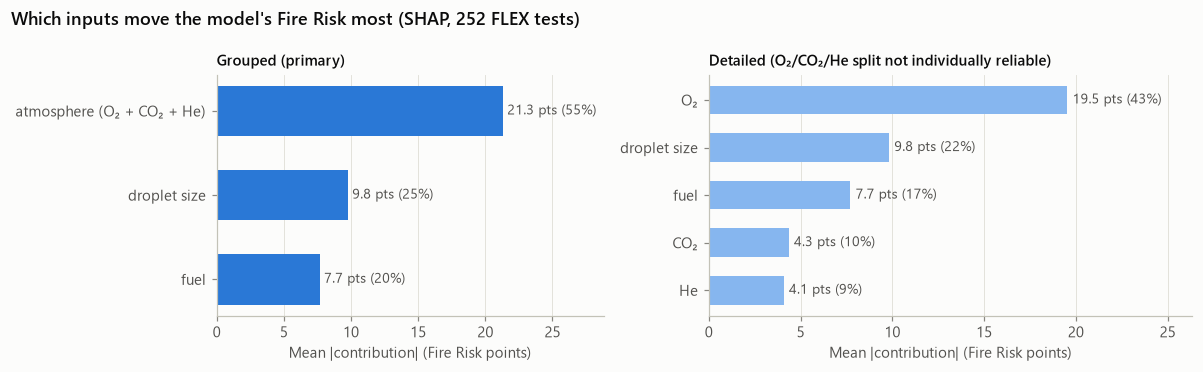

In [2]:
display(imp.round(3))
fig = plots.plot_global_importance(imp[imp["grouping"] == "grouped"], imp[imp["grouping"] == "detailed"])
_ = eda.save(fig, "14_shap_global")

**Read-out.** The atmosphere accounts for ~55% of the model's movement away from the average test
(mean |contribution| 21 points); droplet size ~25% and fuel ~20%. (Standard symmetric SHAP would rank droplet size
lower, 16%, because the opposite slopes of the two fuels partly cancel when the interaction is split evenly.)

In the detailed view CO₂ and He receive ~4 points each. Treat this with caution: the Phase 8 ablation found that
removing the suppressant inputs changes cross-validated skill by +0.002 ROC-AUC (none measurable). The detailed SHAP
split evaluates O₂/suppressant combinations far from the tested diagonal, so it reflects how the fitted coefficients
behave off-manifold more than any evidence about suppressants. This is why the grouped view is primary.

## 2. How contributions depend on the inputs

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


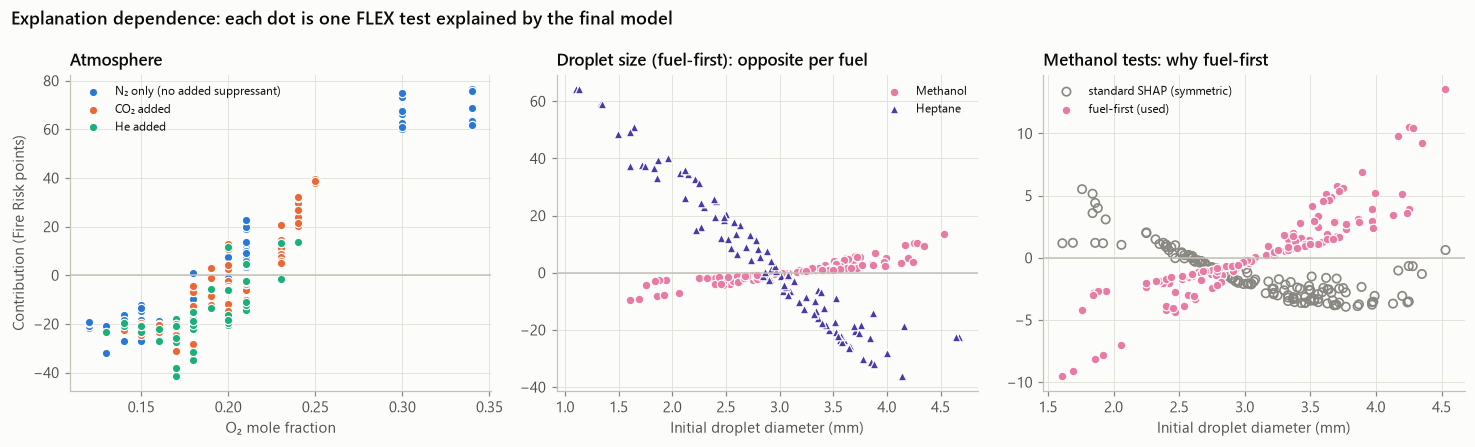

In [3]:
symmetric = pd.read_csv(R / "shap_detailed_symmetric.csv")
fig = plots.plot_dependence(grouped, symmetric)
_ = eda.save(fig, "15_shap_dependence")

**Read-out.**
- **Atmosphere** contribution rises steeply with O₂ for all three diluents — the model's dominant signal.
- **Droplet size** pushes in **opposite directions** for the two fuels: for heptane, small droplets raise the risk
  (up to about +64 points) and large ones lower it (down to about −36); for methanol, larger droplets raise it
  (about −10 to +14). This is the fuel × diameter interaction found in the EDA and confirmed by the ablation.
- **Why fuel-first (right panel):** for the same methanol tests, standard SHAP gives a droplet-size contribution
  that *falls* with diameter — the opposite of the model, whose methanol risk at O₂ 0.21 rises from 19 to 40 as the
  droplet grows from 2 to 4 mm. The fuel-first values follow the model.
- **Fuel** (set first) contributes about −9 points for methanol and +6 for heptane relative to the average test.

## 3. Individual explanations

Four tests chosen by rule (not hand-picked): the highest-risk test, the median ELEVATED and median LOW tests, and
test 151 — the most consistently missed fire from Phase 9.

,example,test_id,fuel,diluent,x_o2,x_co2,x_he,d0_mm,fire_risk,band,outcome_raw
0,highest-risk test,39,Heptane,N2,0.34,0.00,0.0,2.91,99.871,HIGH,Disruption
1,typical ELEVATED test,202,Methanol,N2,0.21,0.00,0.0,3.30,31.968,ELEVATED,Extinction
2,typical LOW test,65,Methanol,N2,0.15,0.00,0.0,3.37,2.752,LOW,Extinction
3,"missed fire (test 151: LOW prediction, but it burned to completion)",151,Methanol,CO2,0.18,0.15,0.0,3.86,7.806,LOW,Completion


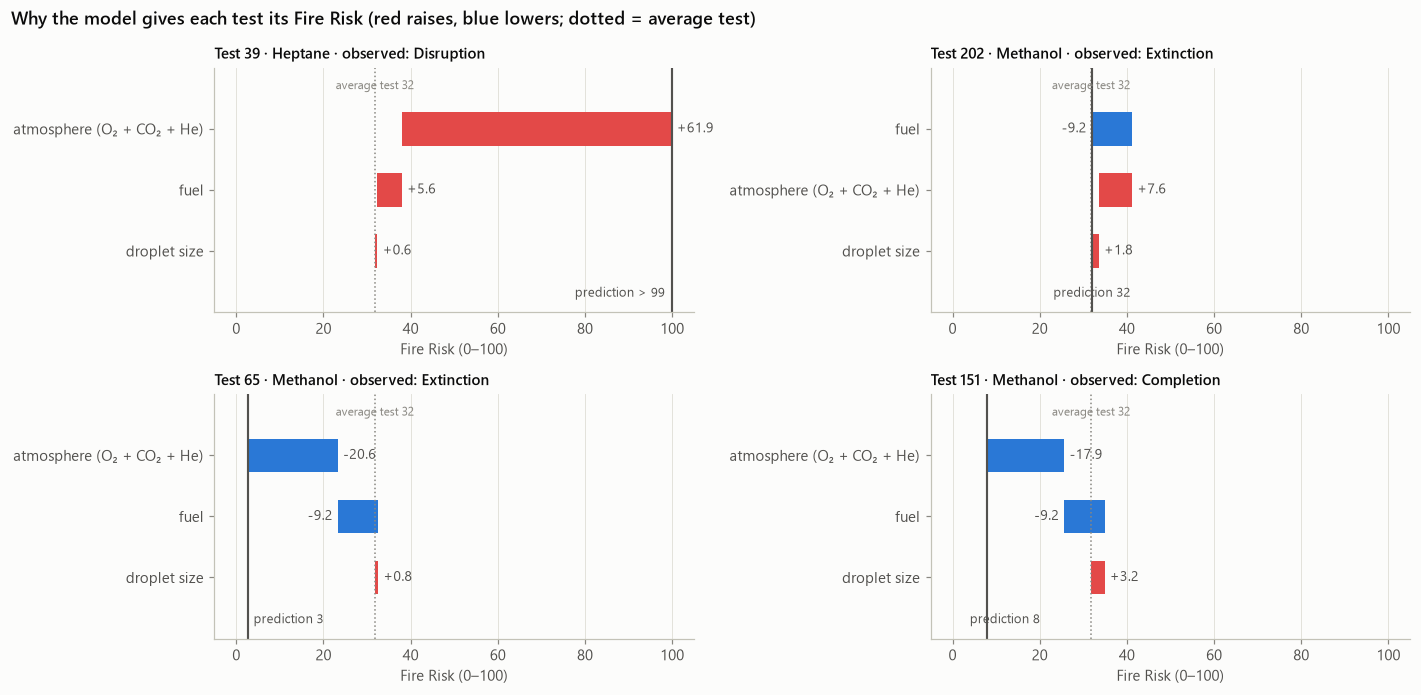

In [4]:
ex = pd.read_csv(R / "examples.csv")
display(ex[["example", "test_id", "fuel", "diluent", "x_o2", "x_co2", "x_he", "d0_mm", "fire_risk", "band", "outcome_raw"]].round(3))
fig, axes = plt.subplots(2, 2, figsize=(13, 6.4))
players = ["fuel", "atmosphere (O₂ + CO₂ + He)", "droplet size"]
for ax, (_, r) in zip(axes.ravel(), ex.iterrows()):
    row = pd.Series({"base": r["base"], "fire_risk": r["fire_risk"], **{p: r[f"phi: {p}"] for p in players}}).astype(float)
    plots.plot_waterfall(row, f"Test {r['test_id']} · {r['fuel']} · observed: {r['outcome_raw']}", ax=ax)
fig.suptitle("Why the model gives each test its Fire Risk (red raises, blue lowers; dotted = average test)",
             x=0.01, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
_ = eda.save(fig, "16_shap_waterfalls")

In [5]:
for _, r in ex.iterrows():
    print(f"[{r['example']}]\n{r['summary']}\n")

[highest-risk test]
Model prediction for a heptane droplet: Fire Risk > 99/100 (HIGH). Compared with the average FLEX test (32/100), atmosphere (O₂ + CO₂ + He) raises it by 62 points; fuel raises it by 6 points. These contributions describe how the model uses the inputs; they are associations learned from NASA FLEX experiments, not measured effects of changing a condition.

[typical ELEVATED test]
Model prediction for a methanol droplet: Fire Risk 32/100 (ELEVATED). Compared with the average FLEX test (32/100), fuel lowers it by 9 points; atmosphere (O₂ + CO₂ + He) raises it by 8 points; droplet size raises it by 2 points. These contributions describe how the model uses the inputs; they are associations learned from NASA FLEX experiments, not measured effects of changing a condition.

[typical LOW test]
Model prediction for a methanol droplet: Fire Risk 3/100 (LOW). Compared with the average FLEX test (32/100), atmosphere (O₂ + CO₂ + He) lowers it by 21 points; fuel lowers it by 9 poin

**Read-out on the missed fire (test 151).** The explanation makes the failure understandable rather than hiding
it: a methanol droplet at O₂ 0.18 with 15% CO₂ — an atmosphere in which most methanol droplets extinguished — so the
atmosphere term pulls the score far below average. The droplet nevertheless burned to completion. The model has no
input that distinguishes this test from its extinguished neighbours; the dashboard will show such LOW predictions
together with the observed 6% sustained rate of the LOW band.

The plain-language summaries are produced by a fixed template from the SHAP numbers (no language model involved),
so they cannot add claims the numbers do not support.

## Summary
| | |
|---|---|
| Method | exact interventional Shapley values on raw inputs, fuel first, Fire Risk points, background = 252 tests |
| Verified | additivity error < 1e-8; symmetric values match `shap.explainers.Exact` to < 1e-9 |
| Global | atmosphere 55%, droplet size 25%, fuel 20% (grouped) |
| Key pattern | droplet size raises risk for methanol but lowers it for heptane |
| Caveat | per-gas split (O₂ vs CO₂ vs He) not individually reliable; all values are associations, not causal effects |

Next (Phase 11): the Streamlit dashboard.